In [1]:
import pybamm

# String-based instructions
Some examples of experiment instructions:

"Discharge at 1C for 0.5 hours"

"Discharge at C/20 for 0.5 hours",

"Charge at 0.5 C for 45 minutes",

"Discharge at 1 A for 90 seconds",

"Charge at 200mA for 45 minutes",

"Discharge at 1 W for 0.5 hours",

"Charge at 200 mW for 45 minutes",

"Rest for 10 minutes",

"Hold at 1 V for 20 seconds",

"Charge at 1 C until 4.1V",

"Hold at 4.1 V until 50 mA",

"Hold at 3V until C/50",

In [2]:
# Define an experiment with a sequence of steps.
experiment = pybamm.Experiment(
    [
        "Discharge at C/10 for 10 hours or until 3.3 V",
        "Rest for 1 hour",
        "Charge at 1 A until 4.1 V",
        "Hold at 4.1 V until 50 mA",
        "Rest for 1 hour",
    ]
)

In [3]:
# Cycle the experiment steps three times, followed by a final discharge step.
experiment = pybamm.Experiment(
    [
        (
            "Discharge at C/10 for 10 hours or until 3.3 V",
            "Rest for 1 hour",
            "Charge at 1 A until 4.1 V",
            "Hold at 4.1 V until 50 mA",
            "Rest for 1 hour",
        )
    ]
    * 3
    + [
        "Discharge at 1C until 3.3 V",
    ]
)

In [4]:
# Simulate the defined experiment.
model = pybamm.lithium_ion.DFN()
sim = pybamm.Simulation(model, experiment=experiment)

In [5]:
sim.solve()
sim.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=40.132353573711406, step=0.40132353573711405…

In [6]:
# Plot a specific cycle of the experiment. The first cycle is indexed as 0, the second as 1, and so on.
sim.solution.cycles[0].plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=13.076782792293887, step=0.13076782792293887…

# Direct instructions

In [7]:
pybamm.step.current(1, duration="1 hour", termination="2.5 V")

Current(1, duration=1 hour, termination=2.5 V)

is equivalent to

In [8]:
pybamm.step.current(1, duration="1 hour", termination="2.5 V")

Current(1, duration=1 hour, termination=2.5 V)

In [9]:
import numpy as np

t = np.linspace(0, 1, 60)       # Create a time array from 0 to 1 second with 60 points
sin_t = 0.5 * np.sin(2 * np.pi * t)     # Create a sine wave with amplitude 0.5 A and period 1 s
drive_cycle_power = np.column_stack([t, sin_t])
experiment = pybamm.Experiment([pybamm.step.power(drive_cycle_power)])
sim = pybamm.Simulation(model, experiment=experiment)
sim.solve()
sim.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

# Example: simulate a long cycling experiment

In [10]:
# Define parameters
parameter_values = pybamm.ParameterValues("Mohtat2020")
parameter_values.update({"SEI kinetic rate constant [m.s-1]": 1e-14})
spm = pybamm.lithium_ion.SPM({"SEI": "ec reaction limited"})

In [11]:
# Calculate stoichiometries at： 1 = 100% SOC
parameter_values.set_initial_stoichiometries(1)

{'Ambient temperature [K]': 298.15,
 'Bulk solvent concentration [mol.m-3]': 2636.0,
 'Cation transference number': 0.38,
 'Cell cooling surface area [m2]': 0.41,
 'Cell volume [m3]': 3.92e-05,
 'Contact resistance [Ohm]': 0,
 'Current function [A]': 5.0,
 'EC diffusivity [m2.s-1]': 2e-18,
 'EC initial concentration in electrolyte [mol.m-3]': 4541.0,
 'Edge heat transfer coefficient [W.m-2.K-1]': 5.0,
 'Electrode height [m]': 1.0,
 'Electrode width [m]': 0.205,
 'Electrolyte conductivity [S.m-1]': <function electrolyte_conductivity_PeymanMPM at 0x11d64f420>,
 'Electrolyte diffusivity [m2.s-1]': <function electrolyte_diffusivity_PeymanMPM at 0x11d64f560>,
 'Exchange-current density for plating [A.m-2]': 0.001,
 'Initial SEI thickness [m]': 5e-09,
 'Initial concentration in electrolyte [mol.m-3]': 1000.0,
 'Initial concentration in negative electrode [mol.m-3]': np.float64(23956.77962073774),
 'Initial concentration in positive electrode [mol.m-3]': np.float64(1186.0769769477972),
 'Init

In [12]:
experiment = pybamm.Experiment(
    [
        (
            "Discharge at 1C until 3V",
            "Rest for 1 hour",
            "Charge at 1C until 4.2V",
            "Hold at 4.2V until C/50",
        )
    ]
    * 500,
    termination="80% capacity",     # Cycle until 80% SOH or 500 cycles, whichever comes first
)
sim = pybamm.Simulation(spm, experiment=experiment, parameter_values=parameter_values)
sol = sim.solve()

In [13]:
# Note sol.plot(...) always uses time as the x-axis.
sol.plot(["Current [A]", "Voltage [V]", "Discharge capacity [A.h]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=147.07029835511702, step=1.4707029835511702)…

In [14]:
# Plot against cycle number instead of time
import numpy as np
import matplotlib.pyplot as plt

capacity_end = np.array([
    np.max(cycle["Discharge capacity [A.h]"].entries)
    for cycle in sol.cycles
])

capacity_retention = 100 * capacity_end / capacity_end[0]

plt.plot(cycles, capacity_retention, "o-")
plt.xlabel("Cycle number")
plt.ylabel("Capacity retention [%]")
plt.show()

NameError: name 'cycles' is not defined

In [ ]:
# Search an OUTPUT variable. Print as a line.
model.variables.search("sei")

# Search and print as a list.
print("\n".join(k for k in model.variables.keys() if "sei" in k.lower()))

Results for 'sei': ['Negative SEI thickness [m]', 'X-averaged negative SEI thickness [m]', 'Negative SEI [m]', 'Negative total SEI thickness [m]', 'X-averaged negative total SEI thickness [m]', 'Negative electrode SEI interfacial current density [A.m-2]', 'X-averaged negative electrode SEI interfacial current density [A.m-2]', 'Positive SEI thickness [m]', 'X-averaged positive SEI thickness [m]', 'Positive SEI [m]', 'Positive total SEI thickness [m]', 'X-averaged positive total SEI thickness [m]', 'Positive electrode SEI interfacial current density [A.m-2]', 'X-averaged positive electrode SEI interfacial current density [A.m-2]', 'Negative SEI on cracks thickness [m]', 'X-averaged negative SEI on cracks thickness [m]', 'Negative SEI on cracks [m]', 'Negative total SEI on cracks thickness [m]', 'X-averaged negative total SEI on cracks thickness [m]', 'Negative electrode SEI on cracks interfacial current density [A.m-2]', 'X-averaged negative electrode SEI on cracks interfacial current d

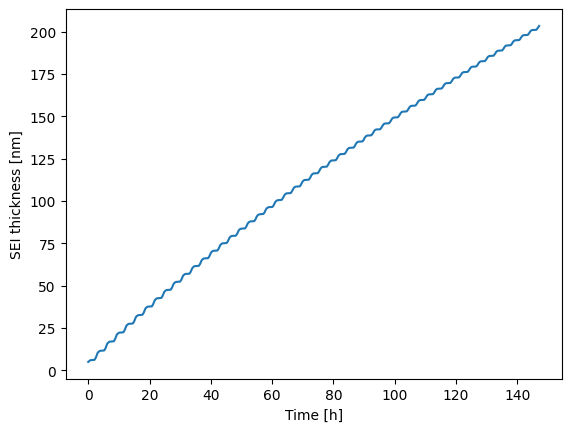

In [ ]:
# Plot SEI thickness against time
time = sol["Time [h]"].entries      # Get stored numerical array from the solution
sei = sol["X-averaged negative total SEI thickness [m]"].entries

plt.plot(time, sei * 1e9)       # SEI in nm
plt.xlabel("Time [h]")
plt.ylabel("SEI thickness [nm]")
plt.show()

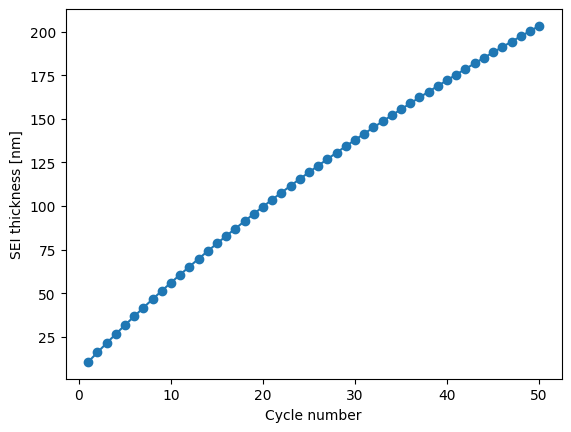

In [ ]:
# Plot SEI thickness against cycle number
cycles = np.arange(1, len(sol.cycles) + 1)      # Create an array of cycle numbers. Note that np.arange(start, stop) does not include the stop value, therefore +1

sei = np.array([
    cycle["X-averaged negative total SEI thickness [m]"].entries[-1]        # Get the last value of the SEI thickness for each cycle
    for cycle in sol.cycles
])

plt.plot(cycles, sei * 1e9, "o-")
plt.xlabel("Cycle number")
plt.ylabel("SEI thickness [nm]")
plt.show()